In [8]:
import numpy as np 
import matplotlib.pyplot as plt
import pickle 
from centralized_solution import Cov, Cov2, solve,plot_me


In [9]:
#on va appliquer avce ce premier graphe le decentralized gradient descent 
#Start with xi0 P Rn at each device i and a stepsize sequence tαkukP
# 2. Sélection des points 
n, m, a = 100, 20, 5


sigma = 0.5      # Bruit 
nu = 1.0         # Régularisation 
n_iter = 20000   # Nombre d'itérations





# 1. Chargement et préparation
with open('first_database.pkl', 'rb') as f:
    x_full, y_full = pickle.load(f)

x = x_full[:n]
y = y_full[:n]

sel = np.arange(n)
ind = np.random.choice(sel, m, replace=False)
x_m = x[ind]

# on charge les matrices Knm et Kmm 
Kmm=Cov(x_m)
Knm=Cov2(x,x_m)

# solution pour le kernel ridge est un alpha * 
a_star= (sigma**2)*Kmm + Knm.T @ Knm + nu*np.eye(m)
b_star=Knm.T@y
alpha_star=np.linalg.solve(a_star,b_star)


#construction de la matrice W 
#graphe complet 
W3 = np.ones((a, a)) / a




C:\Users\BONETTI\AppData\Local\Temp\ipykernel_26876\3045412090.py:17: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  x_full, y_full = pickle.load(f)


In [10]:

#on va débuter le DGD et PUDA 
# 1. on initialise 
alpha_dgd = np.zeros((a,m)) # sequence des alpha necessaires pour le calcul 
alpha_puda = np.zeros((a,m))
alpha_gt= np.zeros((a,m))
g_gt= np.zeros((a,m))
y_puda= np.zeros((a,m))



erreur_dgd=[]
erreur_puda=[]
erreur_gt=[]



#terme non lisse R(w) 
def prox(w,mu):
    return np.sign(w) * np.maximum(np.abs(w)-mu, 0)


#matrices B , A et C pour exact diffisuion 
C=0
B= 0.5* (np.eye(a)-W3)
A_bar= 0.5* (np.eye(a)+W3)




lbd=0.0001
 
#pas  fixe mais on va essayer de trouver une meilleure valeur 
eta=0.001





In [11]:
# --- CALCUL DE LA BORNE THEORIQUE DU PAS (ETA) ---

L_agents = np.zeros(a) # Stocke la constante de Lipschitz (delta) de chaque agent
nu_agents = np.zeros(a) # Stocke la forte convexité de chaque agent

for i in range(a):
    # On reconstruit la Hessienne locale de l'agent i
    # 1. Terme des données : Ki.T @ Ki
    idx_loc = range(i*20, (i+1)*20)
    Ki = Knm[idx_loc, :]
    nabla2_Ji = Ki.T @ Ki 
    
    # 2. Terme de régularisation globale divisé par le nombre d'agents
    nabla2_Ji += (sigma**2 / a) * Kmm 
    nabla2_Ji += (nu / a) * np.eye(m)
    
    # Calcul des valeurs propres
    eigenvals = np.linalg.eigvalsh(nabla2_Ji) # eigvalsh est plus stable pour les matrices symétriques
    L_agents[i] = np.max(eigenvals)
    nu_agents[i] = np.min(eigenvals)

# Constante de Lipschitz globale (delta dans le papier)
delta_L = np.max(L_agents)
# Constante de forte convexité globale
nu_total = np.min(nu_agents)

# Borne théorique du Théorème 1 (avec C=0)
borne_max = 2 / delta_L

print(f"--- Analyse théorique ---")
print(f"Constante de Lipschitz (delta): {delta_L:.4f}")
print(f"Borne max théorique pour eta: {borne_max:.6f}")
print(f"Ton pas actuel (eta): {eta}")

if eta < borne_max:
    print("Résultat: Ton pas est valide selon le Théorème 1.")
else:
    print("ATTENTION: Ton pas est trop grand, risque de divergence !")

--- Analyse théorique ---
Constante de Lipschitz (delta): 244.6142
Borne max théorique pour eta: 0.008176
Ton pas actuel (eta): 0.001
Résultat: Ton pas est valide selon le Théorème 1.


np.float64(0.0015609266470525223)

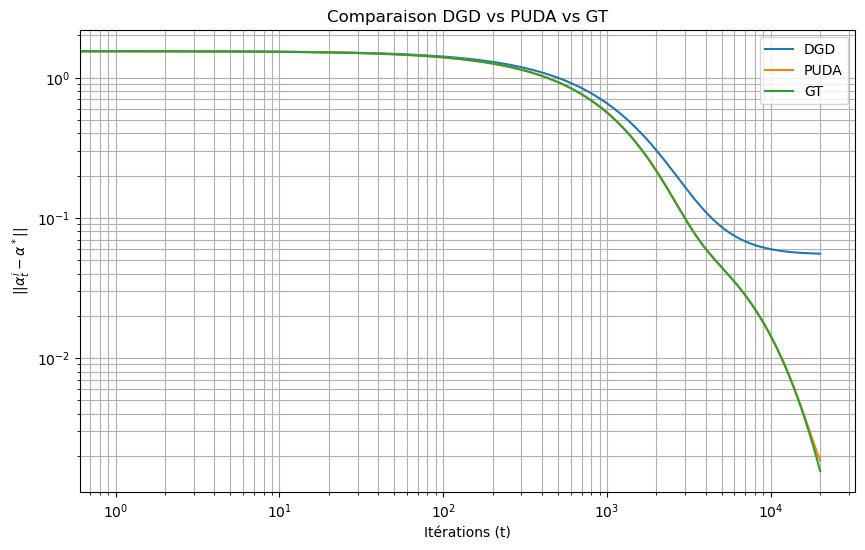

In [12]:

# INITIALISATION
for i in range(a):
    idx_loc = range(i*20, (i+1)*20)
    Ki, yi = Knm[idx_loc, :], y[idx_loc]
    # Gradient à alpha = 0
    g_gt[i] = (sigma**2/a) * Kmm @ alpha_gt[i] + Ki.T @ (Ki @ alpha_gt[i] - yi) + (nu/a) * alpha_gt[i]


for t in range (n_iter):
    
    #on fait les etapes pour DGD 
    new_alpha= np.zeros_like(alpha_dgd)
    for i in range (a): #pour chaque agent 
        idx_loc = range(i*20, (i+1)*20)
        Ki = Knm[idx_loc, :]
        yi = y[idx_loc]
        
        grad_i= (sigma**2/a) * Kmm @ alpha_dgd[i] + Ki.T @ (Ki @ alpha_dgd[i] - yi) + (nu/a) * alpha_dgd[i]
        new_alpha[i] = W3[i, :] @ alpha_dgd - eta * grad_i
        #new_alpha[i] = W3[i, :] @ alpha_dgd - eta_auto* grad_i
    alpha_dgd= new_alpha
    erreur_dgd.append(np.linalg.norm(np.mean(alpha_dgd, axis=0) - alpha_star))

    ########################## GT ##########################
    #on fait pour GT 
    new_alpha_gt= np.zeros_like(alpha_gt)
    #comme vu dans le poly, on a aussi les g pour chaque device 
    new_g=np.zeros_like(g_gt)
    for i in range (a): #pour chaque agent 
        idx_loc = range(i*20, (i+1)*20)
        Ki = Knm[idx_loc, :]
        yi = y[idx_loc]
        
        grad_k= (sigma**2/a) * Kmm @ alpha_gt[i] + Ki.T @ (Ki @ alpha_gt[i] - yi) + (nu/a) * alpha_gt[i]
        # mise à jour alpha
        new_alpha_gt[i] = W3[i, :] @ alpha_gt - eta * g_gt[i]
        #new_alpha_gt[i] = W3[i, :] @ alpha_gt - eta_auto * g_gt[i]
        #on a deux gardeints dans la formule 
        #gard_k est le courant 
        #grad_k1 est le prochain 
        grad_k1= (sigma**2/a) * Kmm @ new_alpha_gt[i] + Ki.T @ (Ki @ new_alpha_gt[i] - yi) + (nu/a) * new_alpha_gt[i]
        
        new_g[i]= W3[i, :] @ g_gt - grad_k + grad_k1
    alpha_gt=new_alpha_gt
    g_gt=new_g
    erreur_gt.append(np.linalg.norm(np.mean(alpha_gt, axis=0) - alpha_star))

    
    #on fait pour PUDA
    new_alpha_2= np.zeros_like(alpha_puda)
    new_y= np.zeros_like(y_puda)
    z=np.zeros_like(alpha_puda)
    for i in range (a): #pour chaque agent 
        idx_loc = range(i*20, (i+1)*20)
        Ki = Knm[idx_loc, :]
        yi = y[idx_loc]
        
        grad_i= (sigma**2/a) * Kmm @ alpha_puda[i] + Ki.T @ (Ki @ alpha_puda[i] - yi) + (nu/a) * alpha_puda[i]
        z[i]= alpha_puda[i] - eta * grad_i - B[i,:] @ y_puda 
    new_y = y_puda + B@ z
    tmp= A_bar @z 
    
    for i in range (a):
        new_alpha_2[i]= prox(tmp[i], eta*lbd)
        #new_alpha_2[i]= prox(tmp[i], eta_auto*lbd)
        
        
    alpha_puda=new_alpha_2
    y_puda= new_y
    
    erreur_puda.append(np.linalg.norm(np.mean(alpha_puda, axis=0) - alpha_star))
    
    
plt.figure(figsize=(10, 6))
plt.loglog(erreur_dgd, label='DGD')
plt.loglog(erreur_puda, label='PUDA')
plt.loglog(erreur_gt, label='GT')
plt.xlabel('Itérations (t)')
plt.ylabel(r'$||\alpha_t^i - \alpha^*||$')
plt.title('Comparaison DGD vs PUDA vs GT')
plt.legend()
plt.grid(True, which="both", ls="-")   
        

erreur_puda[-1]
erreur_dgd[-1]
erreur_gt[-1]